# Ziua 2 - Manipularea datelor și Train/Test Split

În această sesiune vom folosi Pandas pentru a lucra cu date tabelare și vom pregăti un dataset pentru Machine Learning.

La final vei putea:

- să încarci un fișier CSV;
- să inspectezi un `DataFrame`;
- să selectezi și să filtrezi date;
- să identifici și să completezi valori lipsă;
- să creezi vizualizări simple;
- să separi caracteristicile `X` de ținta `y`;
- să împarți datele în seturi de antrenare și test.

## Cum lucrezi în notebook

Rulează celulele în ordine, de sus în jos.

- Celulele **Markdown** conțin explicații și cerințe.
- Celulele **Code** conțin exemple sau zone marcate cu `TODO`.
- Înlocuiește `...` doar în celulele cu exerciții.
- După fiecare exercițiu, rulează și celula de verificare.

## 1. Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

print("Setup complet!")
print("Pandas version:", pd.__version__)

Setup complet!
Pandas version: 3.0.5


## 2. De la dicționare la DataFrame

În sesiunea anterioară am folosit un dicționar pentru a grupa mai multe informații despre același student.

De exemplu, un student poate avea următoarele informații:

- `name`: numele studentului;
- `hours_studied`: numărul de ore studiate;
- `test_score`: scorul obținut.

Un singur dicționar este potrivit pentru un singur student.

Pentru mai mulți studenți putem folosi o listă de dicționare, în care fiecare dicționar descrie un student diferit.

Pandas poate transforma această listă într-un tabel numit `DataFrame`.

Într-un `DataFrame`:

- fiecare dicționar devine o linie;
- fiecare cheie devine numele unei coloane;
- fiecare valoare este plasată în coloana corespunzătoare.

În exemplul nostru:

- fiecare linie reprezintă un student;
- coloana `name` conține numele studenților;
- coloana `hours_studied` conține numărul de ore studiate;
- coloana `test_score` conține scorurile obținute.

Un `DataFrame` seamănă cu un tabel din Excel sau cu un tabel dintr-o bază de date.

Față de o matrice NumPy, un `DataFrame` are câteva avantaje:

- coloanele au nume;
- coloanele pot conține tipuri diferite de date;
- putem selecta datele folosind numele coloanelor;
- avem metode speciale pentru analiză, filtrare și curățare.

Pe scurt, transformăm mai multe dicționare Python într-un tabel Pandas.

In [3]:
students = [
    {
        "name": "Ana",
        "hours_studied": 4.5,
        "test_score": 85,
    },
    {
        "name": "Mihai",
        "hours_studied": 2.0,
        "test_score": 66,
    },
]

example_df = pd.DataFrame(students)
example_df

,name,hours_studied,test_score
0,Ana,4.5,85
1,Mihai,2.0,66


### Task 1 - Completează tabelul

Adaugă un al treilea student în lista `students`, apoi reconstruiește `DataFrame`-ul.

In [ ]:
students = [
    {
        "name": "Ana",
        "hours_studied": 4.5,
        "test_score": 85,
    },
    {
        "name": "Mihai",
        "hours_studied": 2.0,
        "test_score": 66,
    },
    {
        "name": ...,
        "hours_studied": ...,
        "test_score": ...,
    },
]

example_df = ...

example_df

In [ ]:
assert isinstance(example_df, pd.DataFrame)
assert example_df.shape == (3, 3)
assert list(example_df.columns) == [
    "name",
    "hours_studied",
    "test_score",
]

print("Task 1 rezolvat corect.")

## 3. Încărcarea unui fișier CSV

Un fișier CSV păstrează date tabelare sub formă de text.

Vom încărca dataset-ul `students.csv` din folderul `data`.

In [10]:
data_path = Path("../data/students.csv")

if not data_path.exists():
    data_path = Path("data/students.csv")

df = pd.read_csv(data_path)

print("Fișier încărcat din:", data_path)
df.head()

Fișier încărcat din: ../data/students.csv


,student_id,name,hours_studied,exercises_solved,attendance,previous_score,test_score
0,1,Ana,4.5,22,92.0,78.0,85
1,2,Mihai,2.0,11,76.0,64.0,66
2,3,Ioana,5.5,28,96.0,88.0,94
3,4,Andrei,3.0,16,84.0,71.0,76
4,5,Maria,1.5,8,68.0,59.0,57


## 4. Inspectarea dataset-ului

Înainte să modificăm datele, trebuie să înțelegem ce conține dataset-ul.

Cele mai utile operații la început sunt:

- `head()` pentru primele rânduri;
- `shape` pentru numărul de linii și coloane;
- `columns` pentru numele coloanelor;
- `dtypes` pentru tipul fiecărei coloane;
- `describe()` pentru statistici descriptive.

In [11]:
print("Shape:", df.shape)
print("\nColoane:")
print(df.columns)

print("\nTipuri:")
print(df.dtypes)

df.describe()

Shape: (30, 7)

Coloane:
Index(['student_id', 'name', 'hours_studied', 'exercises_solved', 'attendance',
       'previous_score', 'test_score'],
      dtype='str')

Tipuri:
student_id            int64
name                    str
hours_studied       float64
exercises_solved      int64
attendance          float64
previous_score      float64
test_score            int64
dtype: object


,student_id,hours_studied,exercises_solved,attendance,previous_score,test_score
count,30.000000,30.000000,30.00000,27.000000,28.000000,30.000000
mean,15.500000,3.350000,17.60000,82.666667,72.535714,76.033333
std,8.803408,1.565523,7.95071,11.532563,11.970588,14.504419
min,1.000000,0.500000,4.00000,58.000000,49.000000,45.000000
25%,8.250000,2.125000,11.25000,75.500000,64.750000,66.500000
50%,15.500000,3.250000,17.50000,85.000000,73.000000,77.500000
75%,22.750000,4.500000,22.75000,91.500000,80.500000,86.750000
max,30.000000,6.500000,34.00000,99.000000,93.000000,98.000000


### Task 2 - Explorează dataset-ul

Extrage:

- primele `3` rânduri;
- numărul de linii;
- numărul de coloane;
- statisticile descriptive pentru coloanele numerice.

In [ ]:
first_three_rows = ...
number_of_rows = ...
number_of_columns = ...
statistics = ...

print("Linii:", number_of_rows)
print("Coloane:", number_of_columns)

first_three_rows

In [ ]:
assert first_three_rows.shape == (3, 7)
assert number_of_rows == 30
assert number_of_columns == 7
assert isinstance(statistics, pd.DataFrame)
assert "test_score" in statistics.columns

print("Task 2 rezolvat corect.")

## 5. Selectarea coloanelor

Putem selecta o singură coloană folosind numele ei:

```python
df["test_score"]
```

Pentru mai multe coloane, folosim o listă cu numele lor:

```python
df[["hours_studied", "test_score"]]
```

In [12]:
test_scores = df["test_score"]
study_data = df[
    [
        "hours_studied",
        "exercises_solved",
        "test_score",
    ]
]

print(type(test_scores))
print(type(study_data))

study_data.head()

<class 'pandas.Series'>
<class 'pandas.DataFrame'>


,hours_studied,exercises_solved,test_score
0,4.5,22,85
1,2.0,11,66
2,5.5,28,94
3,3.0,16,76
4,1.5,8,57


## 6. Filtrarea rândurilor

Uneori nu vrem să lucrăm cu toate rândurile din dataset, ci doar cu exemplele care respectă o anumită condiție.

De exemplu, putem dori să păstrăm doar studenții care au obținut un scor de cel puțin `80`.

Atunci când comparăm o coloană cu o valoare, Pandas verifică fiecare rând separat și produce o serie de valori `True` și `False`.

Pentru exemplul:

`df["test_score"] >= 80`

rezultatul este `True` pentru studenții care au un scor mai mare sau egal cu `80` și `False` pentru ceilalți.

Această serie de valori se numește mască booleană.

Putem folosi masca pentru a păstra doar rândurile pentru care condiția este `True`.

Astfel, filtrarea urmează pașii:

1. formulăm o condiție;
2. condiția este verificată pentru fiecare rând;
3. păstrăm doar rândurile pentru care rezultatul este `True`.

In [13]:
high_scores = df[df["test_score"] >= 80]

high_scores[
    [
        "name",
        "test_score",
    ]
]

,name,test_score
0,Ana,85
2,Ioana,94
5,Vlad,97
6,Elena,80
8,Sofia,86
10,Daria,91
13,David,87
14,Irina,81
16,Teodora,98
18,Carla,83


Pentru a combina două condiții folosim:

- `&` pentru „și”;
- `|` pentru „sau”.

Fiecare condiție trebuie pusă între paranteze.

In [14]:
selected_students = df[
    (df["hours_studied"] >= 3)
    & (df["attendance"] >= 80)
]

selected_students[
    [
        "name",
        "hours_studied",
        "attendance",
    ]
]

,name,hours_studied,attendance
0,Ana,4.5,92.0
2,Ioana,5.5,96.0
3,Andrei,3.0,84.0
5,Vlad,6.0,98.0
6,Elena,3.5,87.0
10,Daria,5.0,94.0
11,Matei,3.0,81.0
13,David,4.5,90.0
14,Irina,3.5,85.0
16,Teodora,6.5,99.0


### Task 3 - Selectare și filtrare

Creează un tabel care să conțină doar coloanele:

- `name`;
- `hours_studied`;
- `test_score`.

Păstrează doar studenții care au studiat cel puțin `3` ore și au obținut un scor de cel puțin `70`.

In [ ]:
filtered_students = ...

filtered_students

In [ ]:
assert list(filtered_students.columns) == [
    "name",
    "hours_studied",
    "test_score",
]
assert len(filtered_students) == 19
assert (filtered_students["hours_studied"] >= 3).all()
assert (filtered_students["test_score"] >= 70).all()

print("Task 3 rezolvat corect.")

## 7. Valori lipsă

În datele reale, este foarte comun ca anumite informații să nu fie disponibile.

De exemplu, pentru unii studenți poate lipsi valoarea din coloana `attendance` sau scorul anterior din `previous_score`.

În Pandas, o valoare lipsă apare de obicei ca `NaN`.

Înainte să folosim dataset-ul pentru Machine Learning, trebuie să identificăm aceste valori, deoarece mulți algoritmi nu pot lucra direct cu date lipsă.

Metoda `isna()` verifică fiecare valoare din `DataFrame`:

- returnează `True` dacă valoarea lipsește;
- returnează `False` dacă valoarea există.

Dacă aplicăm apoi `sum()`, valorile `True` sunt numărate pentru fiecare coloană.

Astfel, expresia:

`df.isna().sum()`

ne arată câte valori lipsă există în fiecare coloană a dataset-ului.

După ce identificăm valorile lipsă, trebuie să alegem cum le tratăm.

O soluție simplă pentru o coloană numerică este să înlocuim valorile lipsă cu media valorilor existente din acea coloană.

In [15]:
missing_values = df.isna().sum()
missing_values

student_id          0
name                0
hours_studied       0
exercises_solved    0
attendance          3
previous_score      2
test_score          0
dtype: int64

Pentru o coloană numerică, o soluție simplă este să înlocuim valorile lipsă cu media coloanei.

Vom lucra pe o copie a dataset-ului, ca să păstrăm și varianta originală.

In [16]:
clean_df = df.copy()

attendance_mean = clean_df["attendance"].mean()

clean_df["attendance"] = clean_df["attendance"].fillna(
    attendance_mean
)

clean_df.isna().sum()

student_id          0
name                0
hours_studied       0
exercises_solved    0
attendance          0
previous_score      2
test_score          0
dtype: int64

### Task 4 - Completează valorile lipsă

În `clean_df`, completează valorile lipsă din coloana `previous_score` cu media acelei coloane.

La final, coloanele `attendance` și `previous_score` nu trebuie să mai conțină valori lipsă.

In [ ]:
previous_score_mean = ...
clean_df["previous_score"] = ...

clean_df.isna().sum()

In [ ]:
assert clean_df["attendance"].isna().sum() == 0
assert clean_df["previous_score"].isna().sum() == 0
assert clean_df["test_score"].isna().sum() == 0

assert round(previous_score_mean, 2) == 72.54

print("Task 4 rezolvat corect.")

## 8. Vizualizarea datelor

Tabelele ne arată valorile exacte, dar uneori este dificil să observăm rapid un tipar doar citind rândurile dataset-ului.

Graficele ne ajută să explorăm vizual datele și să observăm mai ușor:

- cum sunt distribuite valorile unei caracteristici;
- dacă există valori neobișnuit de mici sau de mari;
- dacă majoritatea exemplelor sunt concentrate într-o anumită zonă;
- dacă două caracteristici par să aibă o relație.

Înainte să antrenăm un model, vizualizarea datelor ne ajută să înțelegem mai bine dataset-ul cu care lucrăm.

### Histograma

O histogramă arată distribuția valorilor unei singure coloane numerice.

Intervalul valorilor este împărțit în mai multe grupuri, iar înălțimea fiecărei bare arată câte exemple se află în acel interval.

În cazul coloanei `test_score`, histograma ne poate arăta:

- în ce interval se află majoritatea scorurilor;
- dacă avem mai mulți studenți cu scoruri mici sau mari;
- dacă există scoruri izolate față de restul valorilor.

Axa orizontală reprezintă intervalele de scoruri, iar axa verticală reprezintă numărul de studenți din fiecare interval.

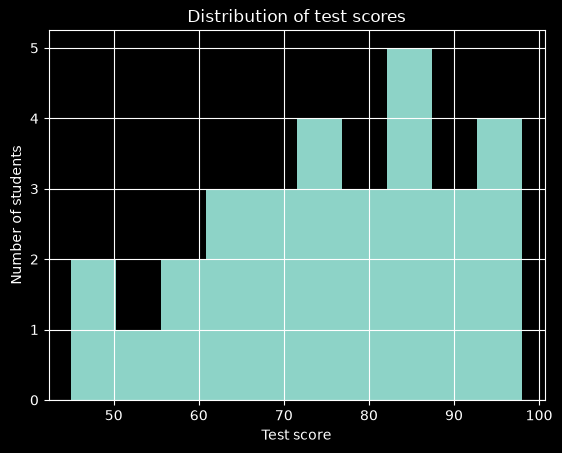

In [17]:
clean_df["test_score"].hist()

plt.xlabel("Test score")
plt.ylabel("Number of students")
plt.title("Distribution of test scores")
plt.show()

### Scatter plot

Histograma analizează o singură caracteristică. Pentru a observa o posibilă relație între două caracteristici numerice, putem folosi un scatter plot.

Într-un scatter plot, fiecare punct reprezintă un exemplu din dataset. În cazul nostru, fiecare punct reprezintă un student:

- poziția pe axa orizontală este dată de `hours_studied`;
- poziția pe axa verticală este dată de `test_score`.

Dacă punctele tind să urce de la stânga la dreapta, putem observa că studenții care au studiat mai multe ore tind să obțină scoruri mai mari.

Acest lucru indică o posibilă relație între cele două caracteristici, dar graficul nu demonstrează automat că una dintre ele o cauzează pe cealaltă.

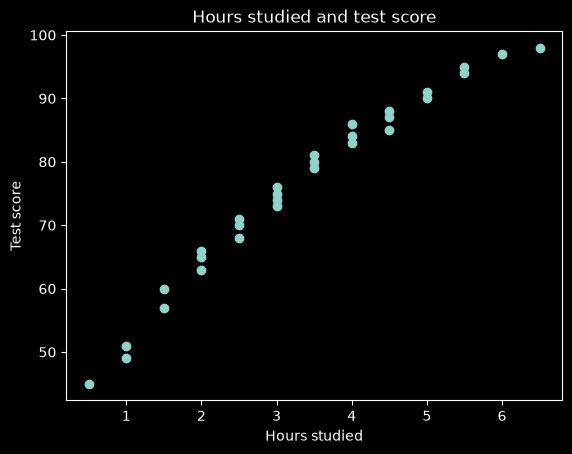

In [18]:
plt.scatter(
    clean_df["hours_studied"],
    clean_df["test_score"],
)

plt.xlabel("Hours studied")
plt.ylabel("Test score")
plt.title("Hours studied and test score")
plt.show()

### Task 5 - Creează un scatter plot

Creează un scatter plot între:

- `exercises_solved` pe axa orizontală;
- `test_score` pe axa verticală.

Adaugă etichete pentru ambele axe și un titlu.

In [ ]:
# TODO: creează scatter plot-ul
...

# TODO: adaugă eticheta axei X
...

# TODO: adaugă eticheta axei Y
...

# TODO: adaugă titlul
...

plt.show()

## 9. Caracteristici și țintă

Într-o problemă de Machine Learning, dataset-ul trebuie separat în două părți cu roluri diferite:

- `X` - caracteristicile folosite de model pentru a face predicții;
- `y` - valoarea pe care modelul trebuie să învețe să o prezică.

### Caracteristicile `X`

`X` conține informațiile de intrare disponibile pentru fiecare exemplu din dataset.

În cazul nostru, fiecare linie reprezintă un student, iar coloanele din `X` descriu activitatea și istoricul său:

- `hours_studied` - numărul de ore studiate;
- `exercises_solved` - numărul de exerciții rezolvate;
- `attendance` - procentul de prezență;
- `previous_score` - scorul obținut anterior.

Modelul va analiza aceste valori și va încerca să învețe o relație între ele și scorul final.

### Ținta `y`

`y` conține valoarea pe care vrem să o prezicem.

În cazul nostru, ținta este:

```text
test_score
```

Pentru fiecare student există:

- o linie în **X**, care conține caracteristicile sale;
- o valoare corespunzătoare în **Y**, care reprezintă scorul real obținut.

De aceea, X și y trebuie să aibă același număr de exemple și să rămână aliniate. De exemplu, dacă prima linie din X conține caracteristicile Anei, prima valoare din y trebuie să fie scorul Anei.

Pe scurt, modelul încearcă să învețe relația:

`caracteristici din X -> valoare din y`

În cazul nostru:

- ore studiate,
- exerciții,
- prezență,
- scor anterior ->
**Toate duc la calcularea scorului la test.**

In [19]:
feature_columns = [
    "hours_studied",
    "exercises_solved",
    "attendance",
    "previous_score",
]

X = clean_df[feature_columns]
y = clean_df["test_score"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (30, 4)
y shape: (30,)


,hours_studied,exercises_solved,attendance,previous_score
0,4.5,22,92.0,78.0
1,2.0,11,76.0,64.0
2,5.5,28,96.0,88.0
3,3.0,16,84.0,71.0
4,1.5,8,68.0,59.0


`X` conține câte un rând pentru fiecare student și câte o coloană pentru fiecare caracteristică.

`y` conține un singur scor pentru fiecare student.

In [23]:
y.head()

0    85
1    66
2    94
3    76
4    57
Name: test_score, dtype: int64

### Task 6 - Construiește `X` și `y`

Creează din nou:

- `X` folosind cele patru caracteristici;
- `y` folosind coloana `test_score`.

Verifică apoi dimensiunile lor.

In [ ]:
X = ...
y = ...

print("X shape:", X.shape)
print("y shape:", y.shape)

In [ ]:
assert isinstance(X, pd.DataFrame)
assert isinstance(y, pd.Series)

assert X.shape == (30, 4)
assert y.shape == (30,)

assert list(X.columns) == [
    "hours_studied",
    "exercises_solved",
    "attendance",
    "previous_score",
]
assert y.name == "test_score"

print("Task 6 rezolvat corect.")

## 10. Train/Test Split

Scopul unui model de Machine Learning nu este doar să ofere rezultate bune pentru exemplele pe care le-a văzut deja, ci să poată face predicții corecte și pentru exemple noi.

De exemplu, modelul nostru ar trebui să poată estima scorul unui student care nu apare în dataset-ul folosit la antrenare.

Dacă folosim toate datele pentru antrenare și apoi evaluăm modelul pe aceleași exemple, rezultatul poate fi înșelător. Modelul poate părea foarte bun doar pentru că a memorat valorile sau particularitățile dataset-ului.

În acest caz, nu știm dacă modelul a învățat o relație generală între caracteristici și scor sau dacă reproduce doar exemplele deja cunoscute.

De aceea împărțim dataset-ul în două părți:

- **train set** - datele folosite pentru antrenarea modelului;
- **test set** - datele păstrate separat și folosite doar pentru evaluare.

Modelul învață folosind `X_train` și `y_train`.

După antrenare, îi oferim `X_test`, iar predicțiile obținute sunt comparate cu valorile reale din `y_test`.

Astfel putem estima cât de bine ar funcționa modelul pe date pe care nu le-a văzut anterior.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (24, 4)
X_test: (6, 4)
y_train: (24,)
y_test: (6,)


Funcția `train_test_split` realizează această împărțire pentru `X` și `y`.

Este important ca cele două structuri să fie împărțite în mod sincronizat.

De exemplu, dacă un anumit student ajunge în `X_test`, scorul său trebuie să ajungă în aceeași poziție în `y_test`. Altfel, caracteristicile unui student ar putea fi asociate cu scorul altui student.

Funcția returnează patru rezultate:

```
X_train, X_test, y_train, y_test
```

Acestea reprezintă:

- **X_train** - caracteristicile folosite pentru antrenare;
- **X_test** - caracteristicile folosite pentru evaluare;
- **y_train** - valorile corecte asociate exemplelor din train set;
- **y_test** - valorile corecte asociate exemplelor din test set.

În exemplul de mai jos:

`test_size=0.2` înseamnă că 20% dintre exemple sunt păstrate pentru test, iar restul de 80% sunt folosite pentru antrenare;
`random_state=42` fixează modul în care sunt alese exemplele, astfel încât să obținem aceeași împărțire la fiecare rulare.

Valoarea 42 nu are o semnificație specială. Poate fi înlocuită cu orice alt număr întreg, dar păstrarea aceleiași valori produce aceeași împărțire și crează rezultatele reproductibile.

In [22]:
print("Indici X_train:", X_train.index.tolist())
print("Indici y_train:", y_train.index.tolist())

print("\nIndici X_test:", X_test.index.tolist())
print("Indici y_test:", y_test.index.tolist())

Indici X_train: [28, 24, 12, 0, 4, 16, 5, 13, 11, 22, 1, 2, 25, 3, 21, 26, 18, 29, 20, 7, 10, 14, 19, 6]
Indici y_train: [28, 24, 12, 0, 4, 16, 5, 13, 11, 22, 1, 2, 25, 3, 21, 26, 18, 29, 20, 7, 10, 14, 19, 6]

Indici X_test: [27, 15, 23, 17, 8, 9]
Indici y_test: [27, 15, 23, 17, 8, 9]


### Task 7 - O altă împărțire

Împarte datele astfel încât:

- 25% dintre exemple să fie în setul de test;
- împărțirea să folosească `random_state=42`.

Afișează dimensiunile celor patru seturi.

In [ ]:
X_train, X_test, y_train, y_test = ...

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

In [ ]:
assert X_train.shape == (22, 4)
assert X_test.shape == (8, 4)
assert y_train.shape == (22,)
assert y_test.shape == (8,)

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

print("Task 7 rezolvat corect.")

## Exercițiu final opțional - Pregătirea completă a dataset-ului

În acest exercițiu vei relua întregul flux parcurs în această sesiune, de la încărcarea datelor până la împărțirea lor în seturi de antrenare și test.

Folosește conceptele și operațiile prezentate anterior în notebook:

- `pd.read_csv()` pentru încărcarea fișierului;
- `isna()` pentru identificarea valorilor lipsă;
- `mean()` pentru calcularea mediei unei coloane;
- `fillna()` pentru completarea valorilor lipsă;
- selectarea coloanelor pentru construirea lui `X` și `y`;
- `train_test_split()` pentru împărțirea dataset-ului;
- `shape` pentru verificarea dimensiunilor finale.

Pornește din nou de la fișierul `students.csv` și parcurge următorii pași:

1. Încarcă dataset-ul într-un nou `DataFrame` numit `final_df`.

2. Verifică dacă există valori lipsă în coloanele:
   - `attendance`;
   - `previous_score`.

3. Calculează media fiecărei coloane și folosește aceste valori pentru a completa datele lipsă.

4. Construiește matricea de caracteristici `X` folosind coloanele:
   - `hours_studied`;
   - `exercises_solved`;
   - `attendance`;
   - `previous_score`.

5. Construiește vectorul țintă `y` folosind coloana:
   - `test_score`.

6. Împarte datele astfel încât:
   - 80% dintre exemple să fie folosite pentru antrenare;
   - 20% dintre exemple să fie păstrate pentru test;
   - împărțirea să folosească `random_state=42`.

7. Afișează dimensiunile pentru:
   - `X_train`;
   - `X_test`;
   - `y_train`;
   - `y_test`.

La final, verifică dacă:

- nu mai există valori lipsă în coloanele folosite;
- `X` și `y` conțin același număr de exemple;
- seturile de train și test au dimensiunile așteptate;
- indicii din `X_train` corespund cu cei din `y_train`;
- indicii din `X_test` corespund cu cei din `y_test`.

In [ ]:
final_df = ...

final_df["attendance"] = ...
final_df["previous_score"] = ...

X = ...
y = ...

X_train, X_test, y_train, y_test = ...

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

In [ ]:
assert final_df["attendance"].isna().sum() == 0
assert final_df["previous_score"].isna().sum() == 0

assert X.shape == (30, 4)
assert y.shape == (30,)

assert X_train.shape == (24, 4)
assert X_test.shape == (6, 4)
assert y_train.shape == (24,)
assert y_test.shape == (6,)

assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)

print("Exercițiul final este rezolvat corect.")